# Análisis de embeddings ESM-2 para mutantes de TP53

Este notebook genera mutantes puntuales de la proteína TP53 humana en posiciones clave del dominio DBD,
calcula embeddings con ESM-2 (`esm2_t33_650M_UR50D`) y compara las distancias (coseno y euclidiana)
entre el wild-type y cada mutante a cuatro niveles de resolución:

- **Global**: promedio de todos los residuos de la proteína
- **Local k=0**: embedding del residuo mutado únicamente
- **Local k=3**: ventana de ±3 residuos alrededor de la mutación
- **Local k=5**: ventana de ±5 residuos alrededor de la mutación

Las posiciones analizadas se agrupan en tres categorías:
- **Hotspots canónicos**: R175, Y220, G245, R248
- **Estructurales**: C176, H179, R249, R282
- **Comparativos del DBD**: T125, A138, P151, V157

## 0. Configuración inicial

Instalación de dependencias e importaciones.

In [ ]:
# Instalar dependencias necesarias
!pip -q install fair-esm biopython scikit-learn matplotlib pandas requests umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.9 MB/s eta 0:00:00


In [ ]:
# ── Importaciones ──
import io
import math
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Bio import SeqIO
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.manifold import TSNE

import torch
import esm
import umap

## 1. Obtención de la secuencia de TP53

Se descarga la secuencia canónica de TP53 humano (UniProt ID: P04637) desde la API de UniProt.

In [ ]:
def fetch_uniprot_fasta(uniprot_id: str):
    """Descarga la secuencia FASTA de una proteína desde UniProt."""
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    record = next(SeqIO.parse(io.StringIO(r.text), "fasta"))
    return str(record.seq), record.description

# Descargar TP53 humano
tp53_seq, tp53_desc = fetch_uniprot_fasta("P04637")

print(tp53_desc)
print("Length:", len(tp53_seq))
print(tp53_seq[:80] + "...")

sp|P04637|P53_HUMAN Cellular tumor antigen p53 OS=Homo sapiens OX=9606 GN=TP53 PE=1 SV=4
Length: 393
MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGPDEAPRMPEAAPPVAPAPAAP...


## 2. Definición de posiciones y grupos

Se seleccionan 12 posiciones del dominio DBD de p53, agrupadas en tres categorías funcionales.
Para cada posición se generarán los 19 mutantes puntuales posibles (los 20 aminoácidos canónicos menos el wild-type).

In [ ]:
# Grupos de posiciones a analizar
position_groups = {
    "Hotspots canónicos": [175, 220, 245, 248],
    "Estructurales": [176, 179, 249, 282],
    "Comparativos del DBD": [125, 138, 151, 157],
}

# Aplanar a lista de tuplas (posición, grupo)
all_positions = []
for group, pos_list in position_groups.items():
    for p in pos_list:
        all_positions.append((p, group))

# Aminoácidos canónicos (20)
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

print("Grupos:", list(position_groups.keys()))

Grupos: ['Hotspots canónicos', 'Estructurales', 'Comparativos del DBD']


In [ ]:
# Mostrar el aminoácido wild-type en cada posición
for pos, group in all_positions:
    wt_aa = tp53_seq[pos - 1]
    print(f"{group:15s} {wt_aa}{pos}")

Hotspots canónicos R175
Hotspots canónicos Y220
Hotspots canónicos G245
Hotspots canónicos R248
Estructurales   C176
Estructurales   H179
Estructurales   R249
Estructurales   R282
Comparativos del DBD T125
Comparativos del DBD A138
Comparativos del DBD P151
Comparativos del DBD V157


## 3. Generación de mutantes

Se generan todas las sustituciones puntuales (19 por posición × 12 posiciones = 228 mutantes).
Cada mutante conserva la secuencia completa de TP53 con un solo aminoácido cambiado.

In [ ]:
def generate_single_mutants_with_metadata(seq, positions_with_groups, amino_acids):
    """Genera todos los mutantes puntuales para las posiciones indicadas.

    Args:
        seq: secuencia de aminoácidos wild-type
        positions_with_groups: lista de tuplas (posición_1based, grupo)
        amino_acids: lista de aminoácidos a probar (20 canónicos)

    Returns:
        Lista de diccionarios con metadatos de cada mutante
    """
    mutants = []
    seq_list = list(seq)

    for pos_1based, group in positions_with_groups:
        idx = pos_1based - 1
        wt_aa = seq_list[idx]

        for aa in amino_acids:
            if aa == wt_aa:
                continue  # omitir la identidad (no es mutación)

            mut_seq = seq_list.copy()
            mut_seq[idx] = aa
            mut_seq = "".join(mut_seq)

            mutants.append({
                "mutant": f"{wt_aa}{pos_1based}{aa}",
                "position": pos_1based,
                "wt_aa": wt_aa,
                "mut_aa": aa,
                "group": group,
                "sequence": mut_seq,
            })

    return mutants

# Generar los 228 mutantes (19 × 12)
mutants = generate_single_mutants_with_metadata(tp53_seq, all_positions, amino_acids)

print("Number of mutants:", len(mutants))
pd.DataFrame(mutants).head()

Number of mutants: 228


,mutant,position,wt_aa,mut_aa,group,sequence
0,R175A,175,R,A,Hotspots canónicos,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...
1,R175C,175,R,C,Hotspots canónicos,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...
2,R175D,175,R,D,Hotspots canónicos,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...
3,R175E,175,R,E,Hotspots canónicos,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...
4,R175F,175,R,F,Hotspots canónicos,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...


## 4. Carga del modelo ESM-2 y funciones de embedding

Se utiliza `esm2_t33_650M_UR50D` (33 capas, 650M parámetros) que produce embeddings de dimensión 1280.
Se definen funciones para extraer representaciones a nivel de residuo y tres estrategias de pooling:

- **Global**: promedio sobre toda la secuencia
- **Local window (k)**: promedio sobre una ventana de ±k residuos alrededor de la mutación
- **Residue only**: embedding del residuo mutado sin contexto (k=0)

In [ ]:
# ── Detectar dispositivo (GPU si está disponible) ──
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Cargar modelo ESM-2 (33 capas, 650M params → embedding dim = 1280)
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()

model.eval()
model = model.to(device)

Device: cuda
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t33_650M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t33_650M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t33_650M_UR50D-contact-regression.pt


In [ ]:
# ── Funciones de embedding ──

def get_residue_representations_batched(
    seqs_with_names,
    model,
    batch_converter,
    device="cpu",
    repr_layer=33,
    batch_size=16
):
    """Calcula las representaciones por residuo para una lista de secuencias.

    Args:
        seqs_with_names: lista de tuplas (nombre, secuencia)
        model: modelo ESM-2 cargado
        batch_converter: convertidor de batches del alfabeto ESM
        device: 'cpu' o 'cuda'
        repr_layer: capa de la cual extraer representaciones (default: 33)
        batch_size: tamaño de lote

    Returns:
        labels: lista de nombres de secuencias
        all_residue_reps: lista de matrices (L, d) por secuencia
    """
    all_labels = []
    all_residue_reps = []

    for start in range(0, len(seqs_with_names), batch_size):
        batch = seqs_with_names[start:start + batch_size]
        batch_labels, batch_strs, batch_tokens = batch_converter(batch)
        batch_tokens = batch_tokens.to(device)

        with torch.no_grad():
            results = model(batch_tokens, repr_layers=[repr_layer], return_contacts=False)

        token_representations = results["representations"][repr_layer]

        for i, seq in enumerate(batch_strs):
            # Extraer solo los tokens de residuos (sin BOS/EOS)
            reps = token_representations[i, 1:len(seq)+1].cpu().numpy()  # (L, d)
            all_labels.append(batch_labels[i])
            all_residue_reps.append(reps)

    return all_labels, all_residue_reps


def global_embedding_from_residue_matrix(residue_matrix):
    """Pooling global: promedio de todos los residuos de la secuencia."""
    return residue_matrix.mean(axis=0)


def local_window_embedding(residue_matrix, pos_1based, k=5):
    """Pooling local: promedio sobre una ventana de ±k residuos."""
    idx = pos_1based - 1
    left = max(0, idx - k)
    right = min(residue_matrix.shape[0], idx + k + 1)
    return residue_matrix[left:right].mean(axis=0)


def residue_only_embedding(residue_matrix, pos_1based):
    """Embedding del residuo individual (k=0, sin contexto)."""
    idx = pos_1based - 1
    return residue_matrix[idx]

## 5. Cálculo de embeddings para WT y mutantes

Se procesan en lote el wild-type y los 228 mutantes (229 secuencias en total).
Cada secuencia produce una matriz de (393, 1280): 393 residuos × 1280 dimensiones.

> ⚠️ Este paso puede tomar varios minutos en una GPU T4.

In [ ]:
# Preparar datos: WT + todos los mutantes
all_sequences = [("WT", tp53_seq)] + [(m["mutant"], m["sequence"]) for m in mutants]

# Calcular representaciones por residuo
labels, residue_reps = get_residue_representations_batched(
    all_sequences,
    model=model,
    batch_converter=batch_converter,
    device=device,
    repr_layer=33,
    batch_size=64,
)

print("Number of sequences:", len(labels))
print("Residue matrix shape for WT:", residue_reps[0].shape)

Number of sequences: 229
Residue matrix shape for WT: (393, 1280)


In [ ]:
# Calcular embeddings globales (pooling sobre toda la secuencia) para todas las secuencias
global_emb = np.vstack([global_embedding_from_residue_matrix(x) for x in residue_reps])
print("Global embedding matrix shape:", global_emb.shape)

Global embedding matrix shape: (229, 1280)


In [ ]:
# Calcular embeddings locales (ventana k=5) para WT + mutantes
wt_emb = global_embedding_from_residue_matrix(residue_reps[0])
k5_emb = np.vstack([wt_emb] + [
    local_window_embedding(x, m["position"], k=5)
    for x, m in zip(residue_reps, mutants)
])
print("Local k=5 embedding matrix shape:", k5_emb.shape)

Local k=5 embedding matrix shape: (229, 1280)


## 6. Cálculo de distancias WT vs mutantes

Para cada mutante se calculan distancias coseno y euclidiana respecto al wild-type
a cuatro niveles de resolución: **global**, **k=0**, **k=3**, **k=5**.

In [ ]:
# ── Precomputar embedding global del WT ──
wt_residue_reps = residue_reps[0]
wt_global_emb = global_embedding_from_residue_matrix(wt_residue_reps).reshape(1, -1)

results = []

for i, m in enumerate(mutants, start=1):
    mut_residue_reps = residue_reps[i]
    pos = m["position"]

    # ── Distancias globales ──
    mut_global_emb = global_embedding_from_residue_matrix(mut_residue_reps).reshape(1, -1)
    global_cos_sim = cosine_similarity(mut_global_emb, wt_global_emb)[0, 0]
    global_cos_dist = 1.0 - global_cos_sim
    global_euc_dist = euclidean_distances(mut_global_emb, wt_global_emb)[0, 0]

    # ── Distancias locales (k=0: solo el residuo mutado) ──
    wt_k0 = residue_only_embedding(wt_residue_reps, pos).reshape(1, -1)
    mut_k0 = residue_only_embedding(mut_residue_reps, pos).reshape(1, -1)
    k0_cos_sim = cosine_similarity(mut_k0, wt_k0)[0, 0]
    k0_cos_dist = 1.0 - k0_cos_sim
    k0_euc_dist = euclidean_distances(mut_k0, wt_k0)[0, 0]

    # ── Distancias locales (k=3) ──
    wt_k3 = local_window_embedding(wt_residue_reps, pos, k=3).reshape(1, -1)
    mut_k3 = local_window_embedding(mut_residue_reps, pos, k=3).reshape(1, -1)
    k3_cos_sim = cosine_similarity(mut_k3, wt_k3)[0, 0]
    k3_cos_dist = 1.0 - k3_cos_sim
    k3_euc_dist = euclidean_distances(mut_k3, wt_k3)[0, 0]

    # ── Distancias locales (k=5) ──
    wt_k5 = local_window_embedding(wt_residue_reps, pos, k=5).reshape(1, -1)
    mut_k5 = local_window_embedding(mut_residue_reps, pos, k=5).reshape(1, -1)
    k5_cos_sim = cosine_similarity(mut_k5, wt_k5)[0, 0]
    k5_cos_dist = 1.0 - k5_cos_sim
    k5_euc_dist = euclidean_distances(mut_k5, wt_k5)[0, 0]

    results.append({
        "mutant": m["mutant"],
        "position": m["position"],
        "wt_aa": m["wt_aa"],
        "mut_aa": m["mut_aa"],
        "group": m["group"],

        "global_cosine_similarity_to_WT": float(global_cos_sim),
        "global_cosine_distance_to_WT": float(global_cos_dist),
        "global_euclidean_distance_to_WT": float(global_euc_dist),

        "k0_cosine_similarity_to_WT": float(k0_cos_sim),
        "k0_cosine_distance_to_WT": float(k0_cos_dist),
        "k0_euclidean_distance_to_WT": float(k0_euc_dist),

        "k3_cosine_similarity_to_WT": float(k3_cos_sim),
        "k3_cosine_distance_to_WT": float(k3_cos_dist),
        "k3_euclidean_distance_to_WT": float(k3_euc_dist),

        "k5_cosine_similarity_to_WT": float(k5_cos_sim),
        "k5_cosine_distance_to_WT": float(k5_cos_dist),
        "k5_euclidean_distance_to_WT": float(k5_euc_dist),
    })

# Construir DataFrame principal con todos los resultados
df = pd.DataFrame(results)
df.head()

,mutant,position,wt_aa,mut_aa,group,global_cosine_similarity_to_WT,global_cosine_distance_to_WT,global_euclidean_distance_to_WT,k0_cosine_similarity_to_WT,k0_cosine_distance_to_WT,k0_euclidean_distance_to_WT,k3_cosine_similarity_to_WT,k3_cosine_distance_to_WT,k3_euclidean_distance_to_WT,k5_cosine_similarity_to_WT,k5_cosine_distance_to_WT,k5_euclidean_distance_to_WT
0,R175A,175,R,A,Hotspots canónicos,0.999950,0.000050,0.086051,0.886312,0.113688,4.545448,0.990167,0.009833,1.085244,0.993308,0.006692,0.896670
1,R175C,175,R,C,Hotspots canónicos,0.999968,0.000032,0.071122,0.905606,0.094394,4.142328,0.990641,0.009359,1.089417,0.994134,0.005866,0.868803
2,R175D,175,R,D,Hotspots canónicos,0.999926,0.000074,0.104173,0.876742,0.123258,4.744982,0.985677,0.014323,1.320025,0.990228,0.009772,1.091273
3,R175E,175,R,E,Hotspots canónicos,0.999918,0.000082,0.110315,0.882806,0.117194,4.637805,0.987850,0.012150,1.214584,0.991417,0.008583,1.021816
4,R175F,175,R,F,Hotspots canónicos,0.999963,0.000037,0.075071,0.889230,0.110770,4.495902,0.989462,0.010538,1.115325,0.993290,0.006710,0.896999


## 7. Estadísticas descriptivas de distancias

Se comparan las distribuciones de distancia coseno en los 4 niveles de resolución.
La distancia global es ~100× menor que la local (k=0), pero conserva el mismo ordenamiento relativo de mutantes.

In [ ]:
# Columnas de distancia coseno a comparar
metric_cols = [
    "global_cosine_distance_to_WT",
    "k0_cosine_distance_to_WT",
    "k3_cosine_distance_to_WT",
    "k5_cosine_distance_to_WT",
]

# Estadísticas descriptivas
df[metric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
global_cosine_distance_to_WT,228.0,0.000026,0.000016,0.000004,0.000014,0.000022,0.000035,0.000082
k0_cosine_distance_to_WT,228.0,0.064621,0.021963,0.012552,0.051029,0.060694,0.079024,0.124642
k3_cosine_distance_to_WT,228.0,0.005495,0.002815,0.001513,0.003547,0.005097,0.006896,0.017042
k5_cosine_distance_to_WT,228.0,0.003311,0.001867,0.000793,0.001949,0.003016,0.004108,0.010893


In [ ]:
# Tabla resumen de métricas con nombres simplificados
df_metric_comparison = df[metric_cols].describe().T
df_metric_comparison = df_metric_comparison.reset_index()
df_metric_comparison = df_metric_comparison[['index', 'mean', 'std', 'min', '50%', 'max']]
df_metric_comparison.columns = ['metric', 'mean', 'std', 'min', '50%', 'max']
df_metric_comparison["metric"] = ["Global", "k0", "k3", "k5"]

# Guardar CSV (usar float_format con precisión adecuada para valores pequeños)
df_metric_comparison.to_csv("metric_comparison.csv", index=False, float_format='%.6f')

df_metric_comparison

,metric,mean,std,min,50%,max
0,Global,0.000026,0.000016,0.000004,0.000022,0.000082
1,k0,0.064621,0.021963,0.012552,0.060694,0.124642
2,k3,0.005495,0.002815,0.001513,0.005097,0.017042
3,k5,0.003311,0.001867,0.000793,0.003016,0.010893


## 8. Visualizaciones de distribuciones de distancia

### 8.1 Boxplot por métrica (escala logarítmica)

Muestra la distribución de distancias coseno en cada nivel de resolución.
La escala logarítmica permite visualizar las diferencias entre niveles (global ~ 1e-5 vs local ~ 1e-2).

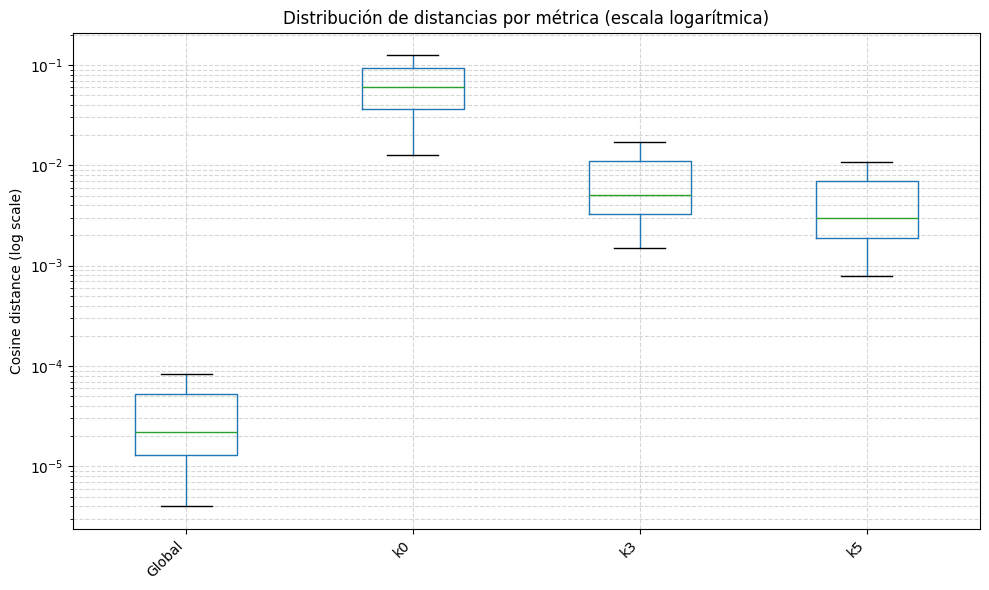

In [ ]:
plt.figure(figsize=(10, 6))
df_metric_comparison.set_index('metric')[['min', '50%', 'max']].T.boxplot()
plt.yscale('log')
plt.title('Distribución de distancias por métrica (escala logarítmica)')
plt.ylabel('Cosine distance (log scale)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("metric_comparison_boxplot.svg")
plt.show()

### 8.2 Boxplots por grupo funcional

Comparación de la distribución de distancias entre los tres grupos de posiciones
para cada nivel de resolución.

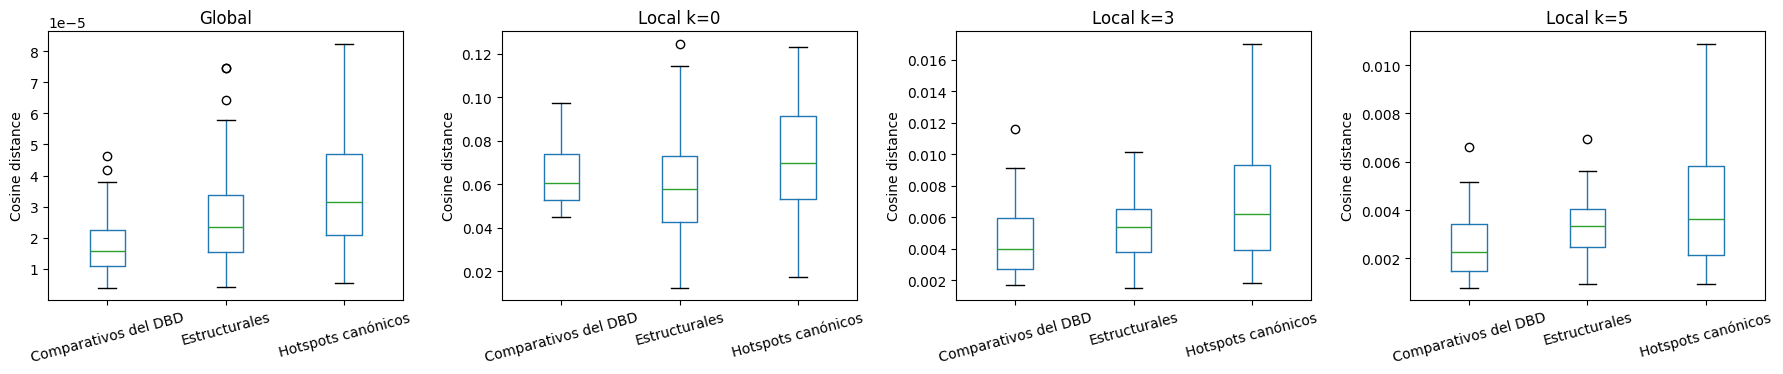

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)

plot_map = [
    ("global_cosine_distance_to_WT", "Global"),
    ("k0_cosine_distance_to_WT", "Local k=0"),
    ("k3_cosine_distance_to_WT", "Local k=3"),
    ("k5_cosine_distance_to_WT", "Local k=5"),
]

for ax, (col, title) in zip(axes, plot_map):
    df.boxplot(column=col, by="group", grid=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Cosine distance")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("")
plt.tight_layout()
plt.show()

## 9. Ranking de mutantes más disruptivos

In [ ]:
# Mostrar el top-10 de mutantes con mayor distancia coseno para cada métrica
for col in metric_cols:
    print("=" * 80)
    print(col)
    display(
        df.sort_values(col, ascending=False)[
            ["mutant", "position", "group", col]
        ].head(10)
    )

global_cosine_distance_to_WT


,mutant,position,group,global_cosine_distance_to_WT
3,R175E,175,Hotspots canónicos,0.000082
62,R248G,248,Hotspots canónicos,0.000077
119,R249G,249,Estructurales,0.000075
116,R249D,249,Estructurales,0.000075
2,R175D,175,Hotspots canónicos,0.000074
136,R282E,282,Estructurales,0.000064
45,G245K,245,Hotspots canónicos,0.000060
57,R248A,248,Hotspots canónicos,0.000059
71,R248S,248,Hotspots canónicos,0.000059
51,G245R,245,Hotspots canónicos,0.000059


k0_cosine_distance_to_WT


,mutant,position,group,k0_cosine_distance_to_WT
95,H179A,179,Estructurales,0.124642
2,R175D,175,Hotspots canónicos,0.123258
3,R175E,175,Hotspots canónicos,0.117194
100,H179G,179,Estructurales,0.114180
0,R175A,175,Hotspots canónicos,0.113688
16,R175V,175,Hotspots canónicos,0.111780
14,R175S,175,Hotspots canónicos,0.111735
4,R175F,175,Hotspots canónicos,0.110770
108,H179R,179,Estructurales,0.108073
46,G245L,245,Hotspots canónicos,0.107703


k3_cosine_distance_to_WT


,mutant,position,group,k3_cosine_distance_to_WT
49,G245P,245,Hotspots canónicos,0.017042
38,G245A,245,Hotspots canónicos,0.014754
2,R175D,175,Hotspots canónicos,0.014323
46,G245L,245,Hotspots canónicos,0.014087
62,R248G,248,Hotspots canónicos,0.013791
3,R175E,175,Hotspots canónicos,0.012150
9,R175L,175,Hotspots canónicos,0.011855
192,P151D,151,Comparativos del DBD,0.011584
12,R175P,175,Hotspots canónicos,0.011504
16,R175V,175,Hotspots canónicos,0.011240


k5_cosine_distance_to_WT


,mutant,position,group,k5_cosine_distance_to_WT
49,G245P,245,Hotspots canónicos,0.010893
38,G245A,245,Hotspots canónicos,0.010316
2,R175D,175,Hotspots canónicos,0.009772
46,G245L,245,Hotspots canónicos,0.009524
3,R175E,175,Hotspots canónicos,0.008583
62,R248G,248,Hotspots canónicos,0.008129
9,R175L,175,Hotspots canónicos,0.007739
12,R175P,175,Hotspots canónicos,0.007518
54,G245V,245,Hotspots canónicos,0.007258
16,R175V,175,Hotspots canónicos,0.007193


### Top 25 mutantes por k=5

Comparación de las 4 métricas para los 25 mutantes con mayor distancia en k=5.

In [ ]:
df.sort_values("k5_cosine_distance_to_WT", ascending=False)[
    [
        "mutant", "position", "group",
        "global_cosine_distance_to_WT",
        "k0_cosine_distance_to_WT",
        "k3_cosine_distance_to_WT",
        "k5_cosine_distance_to_WT",
    ]
].head(25)

,mutant,position,group,global_cosine_distance_to_WT,k0_cosine_distance_to_WT,k3_cosine_distance_to_WT,k5_cosine_distance_to_WT
49,G245P,245,Hotspots canónicos,0.000045,0.092798,0.017042,0.010893
38,G245A,245,Hotspots canónicos,0.000042,0.100149,0.014754,0.010316
2,R175D,175,Hotspots canónicos,0.000074,0.123258,0.014323,0.009772
46,G245L,245,Hotspots canónicos,0.000054,0.107703,0.014087,0.009524
3,R175E,175,Hotspots canónicos,0.000082,0.117194,0.012150,0.008583
62,R248G,248,Hotspots canónicos,0.000077,0.090978,0.013791,0.008129
9,R175L,175,Hotspots canónicos,0.000046,0.107621,0.011855,0.007739
12,R175P,175,Hotspots canónicos,0.000044,0.095435,0.011504,0.007518
54,G245V,245,Hotspots canónicos,0.000038,0.095909,0.010980,0.007258
16,R175V,175,Hotspots canónicos,0.000045,0.111780,0.011240,0.007193


### Heatmaps de distancia por posición y aminoácido mutante

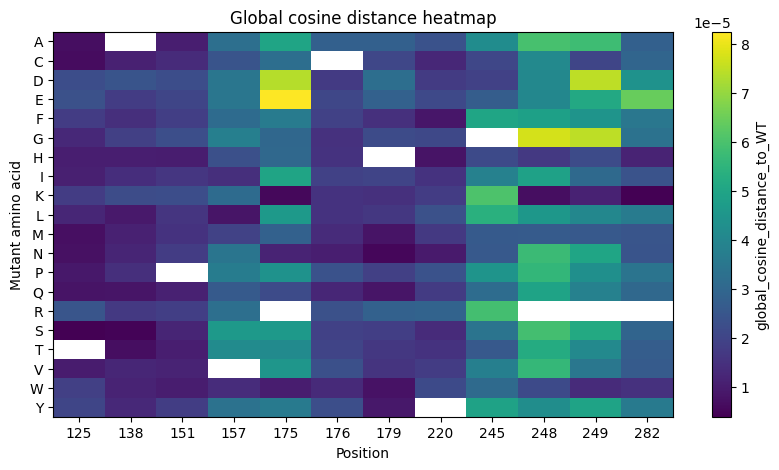

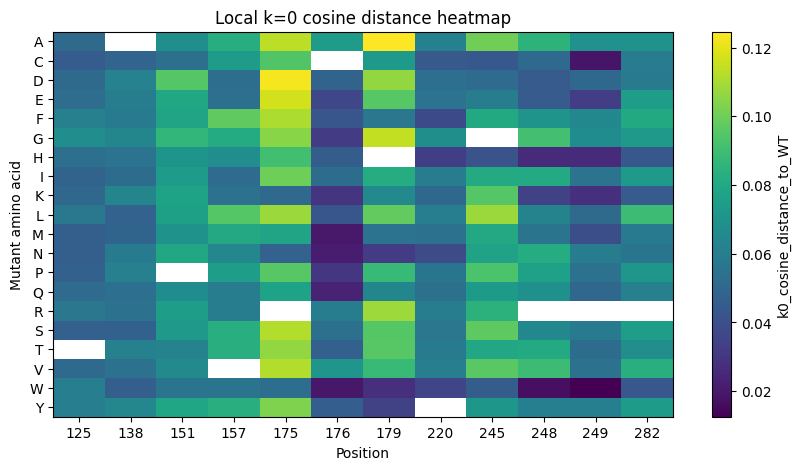

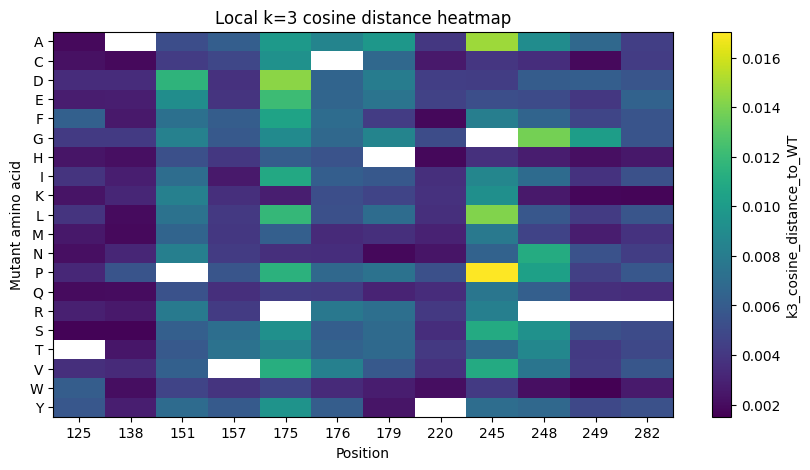

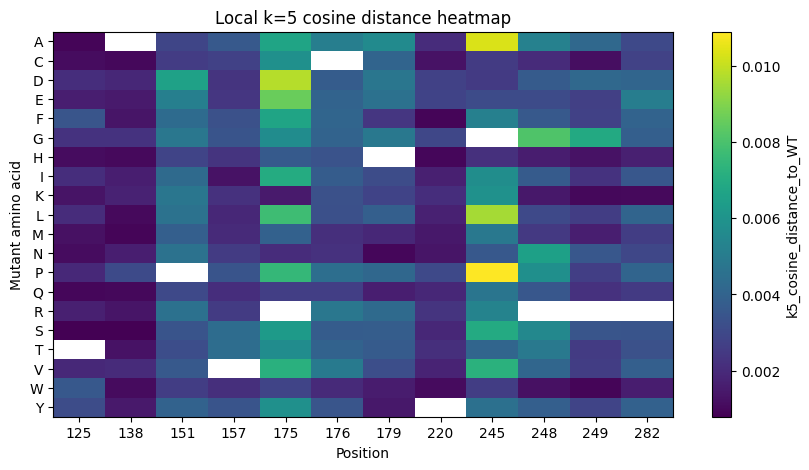

In [ ]:
def plot_heatmap(df, value_col, title):
    """Heatmap: filas = aminoácido mutante, columnas = posición."""
    heat = df.pivot(index="mut_aa", columns="position", values=value_col)

    plt.figure(figsize=(10, 5))
    plt.imshow(heat.values, aspect="auto")
    plt.xticks(range(len(heat.columns)), heat.columns)
    plt.yticks(range(len(heat.index)), heat.index)
    plt.colorbar(label=value_col)
    plt.xlabel("Position")
    plt.ylabel("Mutant amino acid")
    plt.title(title)
    plt.show()

plot_heatmap(df, "global_cosine_distance_to_WT", "Global cosine distance heatmap")
plot_heatmap(df, "k0_cosine_distance_to_WT", "Local k=0 cosine distance heatmap")
plot_heatmap(df, "k3_cosine_distance_to_WT", "Local k=3 cosine distance heatmap")
plot_heatmap(df, "k5_cosine_distance_to_WT", "Local k=5 cosine distance heatmap")

## 10. Resumen agregado por posición

Se calculan estadísticas (media, mediana, std, max) de las distancias coseno
agrupando los 19 mutantes por cada posición.

In [ ]:
summary_by_position = (
    df.groupby(["group", "position", "wt_aa"], as_index=False)
      .agg(
          n_mutants=("mutant", "count"),

          global_mean=("global_cosine_distance_to_WT", "mean"),
          global_median=("global_cosine_distance_to_WT", "median"),
          global_std=("global_cosine_distance_to_WT", "std"),
          global_max=("global_cosine_distance_to_WT", "max"),

          k0_mean=("k0_cosine_distance_to_WT", "mean"),
          k0_median=("k0_cosine_distance_to_WT", "median"),
          k0_std=("k0_cosine_distance_to_WT", "std"),
          k0_max=("k0_cosine_distance_to_WT", "max"),

          k3_mean=("k3_cosine_distance_to_WT", "mean"),
          k3_median=("k3_cosine_distance_to_WT", "median"),
          k3_std=("k3_cosine_distance_to_WT", "std"),
          k3_max=("k3_cosine_distance_to_WT", "max"),

          k5_mean=("k5_cosine_distance_to_WT", "mean"),
          k5_median=("k5_cosine_distance_to_WT", "median"),
          k5_std=("k5_cosine_distance_to_WT", "std"),
          k5_max=("k5_cosine_distance_to_WT", "max"),
      )
)

summary_by_position["site"] = (
    summary_by_position["wt_aa"] + summary_by_position["position"].astype(str)
)
summary_by_position.sort_values("k5_mean", ascending=False)

,group,position,wt_aa,n_mutants,global_mean,global_median,global_std,global_max,k0_mean,k0_median,...,k0_max,k3_mean,k3_median,k3_std,k3_max,k5_mean,k5_median,k5_std,k5_max,site
8,Hotspots canónicos,175,R,19,0.000038,0.000037,0.000019,0.000082,0.094656,0.103086,...,0.123258,0.008721,0.009359,0.003231,0.014323,0.005653,0.005882,0.002282,0.009772,R175
10,Hotspots canónicos,245,G,19,0.000037,0.000034,0.000013,0.000060,0.076796,0.080284,...,0.107703,0.008374,0.007789,0.003785,0.017042,0.005360,0.004852,0.002625,0.010893,G245
2,Comparativos del DBD,151,P,19,0.000016,0.000016,0.000004,0.000023,0.073129,0.074005,...,0.095086,0.006940,0.006962,0.001760,0.011584,0.003985,0.003968,0.001028,0.006592,P151
11,Hotspots canónicos,248,R,19,0.000045,0.000048,0.000017,0.000077,0.062540,0.065000,...,0.090978,0.006781,0.006544,0.003091,0.013791,0.003871,0.003676,0.001817,0.008129,R248
4,Estructurales,176,C,19,0.000018,0.000019,0.000005,0.000028,0.041985,0.042475,...,0.074205,0.005978,0.006184,0.001525,0.008537,0.003630,0.003736,0.000897,0.005112,C176
5,Estructurales,179,H,19,0.000018,0.000017,0.000008,0.000032,0.079293,0.088513,...,0.124642,0.005789,0.006752,0.002264,0.009757,0.003302,0.003689,0.001334,0.005616,H179
7,Estructurales,282,R,19,0.000029,0.000029,0.000013,0.000064,0.066255,0.069540,...,0.089448,0.004621,0.005036,0.001272,0.006377,0.003233,0.003422,0.001016,0.005077,R282
3,Comparativos del DBD,157,V,19,0.000029,0.000033,0.000010,0.000046,0.071375,0.074062,...,0.097253,0.004776,0.004214,0.001321,0.007354,0.002761,0.002555,0.000845,0.004417,V157
6,Estructurales,249,R,19,0.000041,0.000041,0.000018,0.000075,0.047737,0.052284,...,0.069458,0.004322,0.004209,0.002037,0.010174,0.002720,0.002637,0.001406,0.006937,R249
9,Hotspots canónicos,220,Y,19,0.000018,0.000018,0.000006,0.000029,0.052617,0.055182,...,0.068493,0.003537,0.003617,0.001026,0.005322,0.001909,0.001900,0.000649,0.003006,Y220


## 11. Comparación global vs local (k=5) por posición

Se calcula delta = k5_mean − global_mean para cada posición.
Un delta alto indica que la posición es más sensible a nivel local que global.

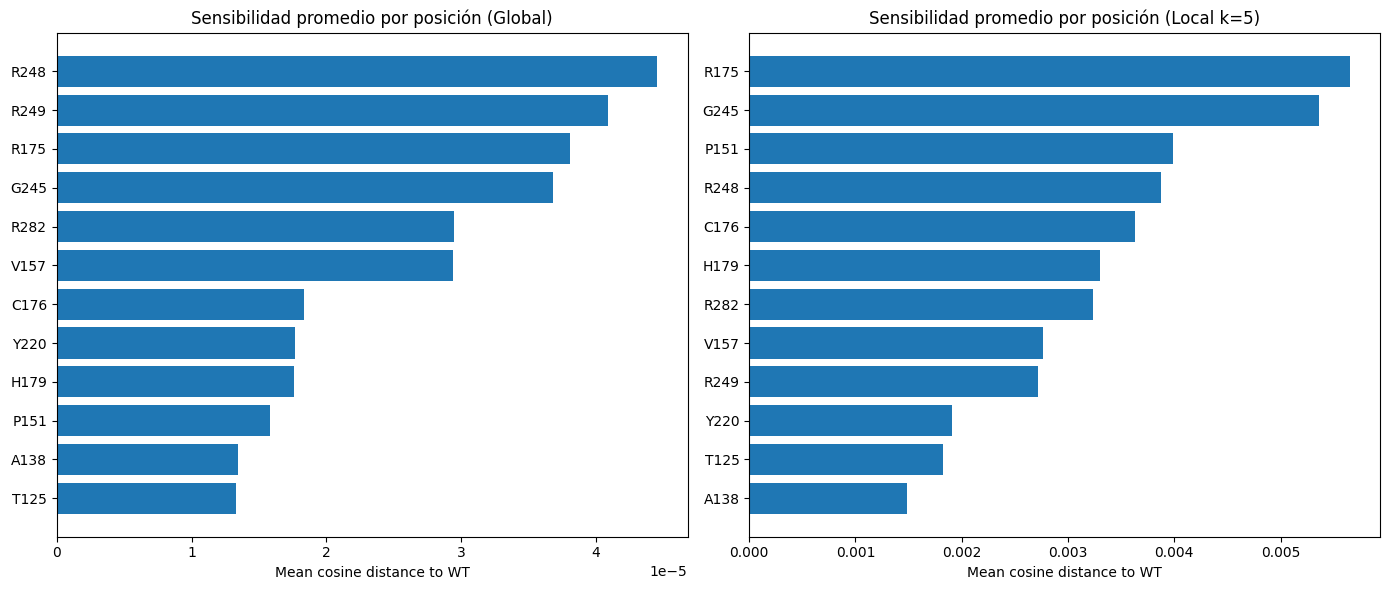

In [ ]:
# Ranking de sensibilidad por posición: Global vs Local k=5
rank_global = summary_by_position.sort_values("global_mean", ascending=False)[["site", "global_mean"]].reset_index(drop=True)
rank_k5 = summary_by_position.sort_values("k5_mean", ascending=False)[["site", "k5_mean"]].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

tmp = summary_by_position.sort_values("global_mean", ascending=True)
axes[0].barh(tmp["site"], tmp["global_mean"])
axes[0].set_title("Sensibilidad promedio por posición (Global)")
axes[0].set_xlabel("Mean cosine distance to WT")

tmp = summary_by_position.sort_values("k5_mean", ascending=True)
axes[1].barh(tmp["site"], tmp["k5_mean"])
axes[1].set_title("Sensibilidad promedio por posición (Local k=5)")
axes[1].set_xlabel("Mean cosine distance to WT")

plt.tight_layout()
plt.savefig("average-sensitivity-by-position-global-vs-k5.svg")
plt.show()

### Delta k5 − Global

Diferencia entre la sensibilidad local (k=5) y global por posición.

In [ ]:
compare_rank = summary_by_position[["site", "group", "global_mean", "k5_mean"]].copy()
compare_rank["delta_k5_minus_global"] = compare_rank["k5_mean"] - compare_rank["global_mean"]
compare_rank = compare_rank.sort_values("delta_k5_minus_global", ascending=False)

compare_rank

,site,group,global_mean,k5_mean,delta_k5_minus_global
8,R175,Hotspots canónicos,0.000038,0.005653,0.005615
10,G245,Hotspots canónicos,0.000037,0.005360,0.005323
2,P151,Comparativos del DBD,0.000016,0.003985,0.003969
11,R248,Hotspots canónicos,0.000045,0.003871,0.003826
4,C176,Estructurales,0.000018,0.003630,0.003612
5,H179,Estructurales,0.000018,0.003302,0.003285
7,R282,Estructurales,0.000029,0.003233,0.003203
3,V157,Comparativos del DBD,0.000029,0.002761,0.002732
6,R249,Estructurales,0.000041,0.002720,0.002679
9,Y220,Hotspots canónicos,0.000018,0.001909,0.001891


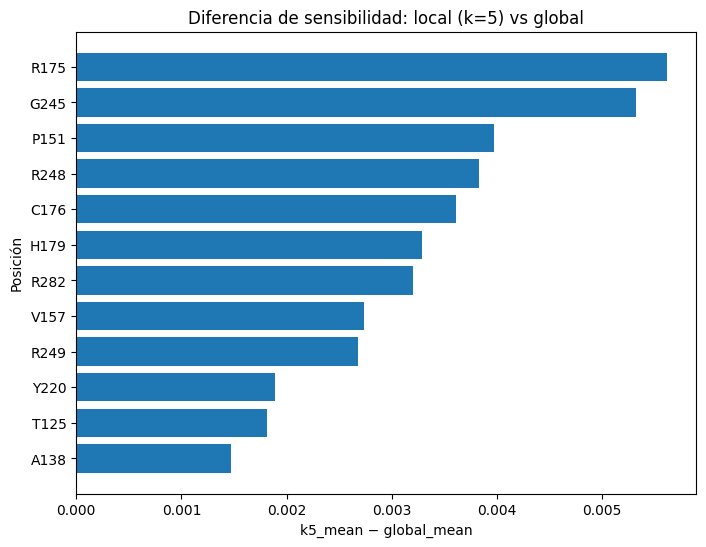

In [ ]:
tmp = compare_rank.sort_values("delta_k5_minus_global", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(tmp["site"], tmp["delta_k5_minus_global"])
plt.xlabel("k5_mean − global_mean")
plt.ylabel("Posición")
plt.title("Diferencia de sensibilidad: local (k=5) vs global")
plt.savefig("compare_rank.svg")
plt.show()

In [ ]:
compare_rank.to_csv("compare_rank.csv", index=False)

## 12. Reducción de dimensionalidad (PCA, TSNE, UMAP)

Se proyectan los embeddings a 2D para visualizar el agrupamiento de mutantes.
Se usan tres técnicas complementarias: PCA (lineal), TSNE (no lineal, conserva estructura local) y UMAP (no lineal, rápido).

### 12.1 PCA – Embeddings globales

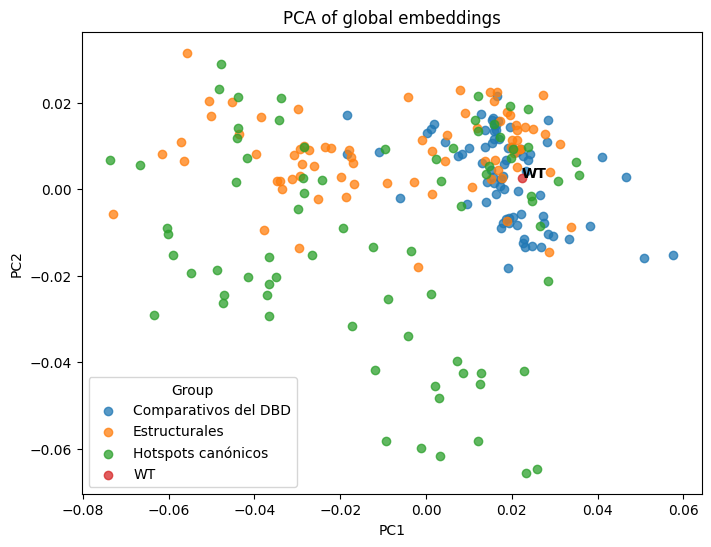

In [ ]:
# Construir labels: WT + grupo de cada mutante
group_list = ["WT"] + [m["group"] for m in mutants]

# PCA sobre embeddings globales
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(global_emb)

plot_df = pd.DataFrame({
    "label": group_list,
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
})

plt.figure(figsize=(8, 6))
for g in np.unique(plot_df["label"]):
    sub = plot_df[plot_df["label"] == g]
    if len(sub) > 0:
        plt.scatter(sub["PC1"], sub["PC2"], label=g, alpha=0.75)

wt_row = plot_df.iloc[0]
plt.annotate("WT", (wt_row["PC1"], wt_row["PC2"]), fontsize=10, fontweight="bold")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of global embeddings")
plt.legend(title="Group")
plt.savefig("pca-global-embeddings.svg")
plt.show()

### 12.2 TSNE – Embeddings globales

TSNE con métrica coseno. Se aplica StandardScaler antes para mejorar la convergencia.

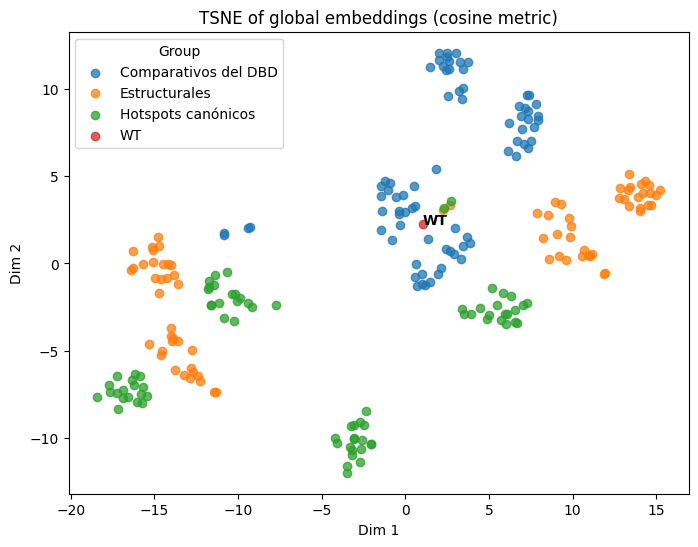

In [ ]:
# Escalar antes de TSNE para mejor estabilidad numérica
global_emb_scaled = StandardScaler().fit_transform(global_emb)

coords = TSNE(n_components=2, metric='cosine', random_state=42).fit_transform(global_emb_scaled)

plot_df = pd.DataFrame({
    "label": group_list,
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
})

plt.figure(figsize=(8, 6))
for g in np.unique(plot_df["label"]):
    sub = plot_df[plot_df["label"] == g]
    if len(sub) > 0:
        plt.scatter(sub["PC1"], sub["PC2"], label=g, alpha=0.75)

wt_row = plot_df.iloc[0]
plt.annotate("WT", (wt_row["PC1"], wt_row["PC2"]), fontsize=10, fontweight="bold")

plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.title("TSNE of global embeddings (cosine metric)")
plt.legend(title="Group")
plt.savefig("tsne-global-embeddings.svg")
plt.show()

### 12.3 UMAP – Embeddings globales

UMAP con métrica coseno. Se fija `random_state` para reproducibilidad.

Shape embeddings: (229, 1280)
Número de labels: 229


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


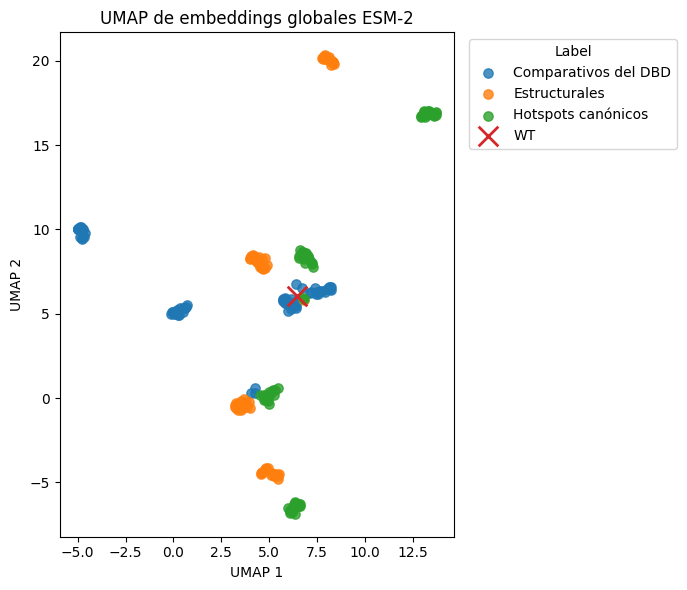

In [ ]:
X = global_emb
labels_arr = group_list

print("Shape embeddings:", X.shape)
print("Número de labels:", len(labels_arr))

assert X.shape[0] == len(labels_arr), "Mismatch entre embeddings y labels"

# Escalar antes de UMAP
X_scaled = StandardScaler().fit_transform(X)

# UMAP con random_state fijo para reproducibilidad
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)

X_umap = reducer.fit_transform(X_scaled)

df_umap = pd.DataFrame({
    "UMAP1": X_umap[:, 0],
    "UMAP2": X_umap[:, 1],
    "label": labels_arr,
})

plt.figure(figsize=(7, 6))
for label in np.unique(labels_arr):
    subset = df_umap[df_umap["label"] == label]
    if label == "WT":
        plt.scatter(subset["UMAP1"], subset["UMAP2"], label=label,
                    alpha=1.0, s=200, marker="x", linewidths=2)
    else:
        plt.scatter(subset["UMAP1"], subset["UMAP2"], label=label,
                    alpha=0.8, s=45)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP de embeddings globales ESM-2")
plt.legend(title="Label", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 12.4 PCA + UMAP – Embeddings globales

Se aplica PCA (50 componentes) como preprocesamiento antes de UMAP
para reducir ruido y acelerar el cálculo.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


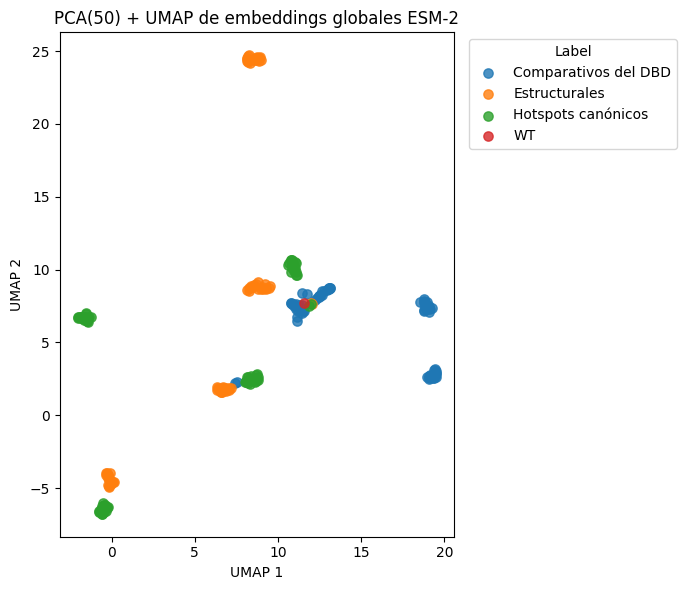

In [ ]:
X_scaled = StandardScaler().fit_transform(global_emb)

X_pca = PCA(n_components=50, random_state=42).fit_transform(X_scaled)

X_umap = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
).fit_transform(X_pca)

df_umap = pd.DataFrame({
    "UMAP1": X_umap[:, 0],
    "UMAP2": X_umap[:, 1],
    "label": labels_arr,
})

plt.figure(figsize=(7, 6))
for label in np.unique(labels_arr):
    subset = df_umap[df_umap["label"] == label]
    plt.scatter(subset["UMAP1"], subset["UMAP2"], label=label, alpha=0.8, s=45)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("PCA(50) + UMAP de embeddings globales ESM-2")
plt.legend(title="Label", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 12.5 PCA – Embeddings locales k=5

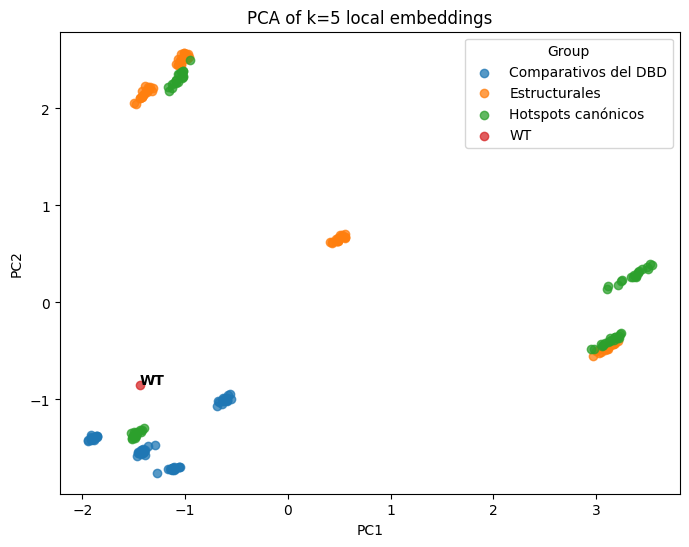

In [ ]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(k5_emb)

plot_df = pd.DataFrame({
    "label": group_list,
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
})

plt.figure(figsize=(8, 6))
for g in np.unique(plot_df["label"]):
    sub = plot_df[plot_df["label"] == g]
    if len(sub) > 0:
        plt.scatter(sub["PC1"], sub["PC2"], label=g, alpha=0.75)

wt_row = plot_df.iloc[0]
plt.annotate("WT", (wt_row["PC1"], wt_row["PC2"]), fontsize=10, fontweight="bold")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of k=5 local embeddings")
plt.legend(title="Group")
plt.savefig("pca-k5-embeddings.svg")
plt.show()

### 12.6 TSNE – Embeddings locales k=5

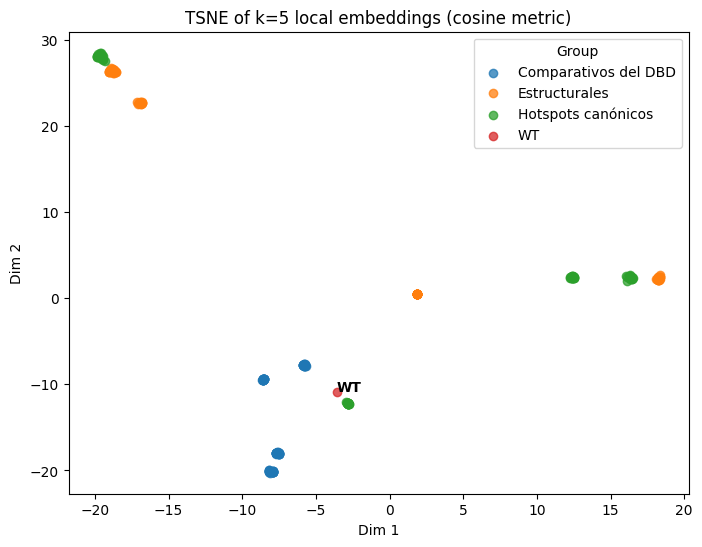

In [ ]:
k5_emb_scaled = StandardScaler().fit_transform(k5_emb)

coords = TSNE(n_components=2, metric='cosine', random_state=42).fit_transform(k5_emb_scaled)

plot_df = pd.DataFrame({
    "label": group_list,
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
})

plt.figure(figsize=(8, 6))
for g in np.unique(plot_df["label"]):
    sub = plot_df[plot_df["label"] == g]
    if len(sub) > 0:
        plt.scatter(sub["PC1"], sub["PC2"], label=g, alpha=0.75)

wt_row = plot_df.iloc[0]
plt.annotate("WT", (wt_row["PC1"], wt_row["PC2"]), fontsize=10, fontweight="bold")

plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.title("TSNE of k=5 local embeddings (cosine metric)")
plt.legend(title="Group")
plt.savefig("tsne-k5-embeddings.svg")
plt.show()

### 12.7 UMAP – Embeddings locales k=5

Shape embeddings: (229, 1280)
Número de labels: 229


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


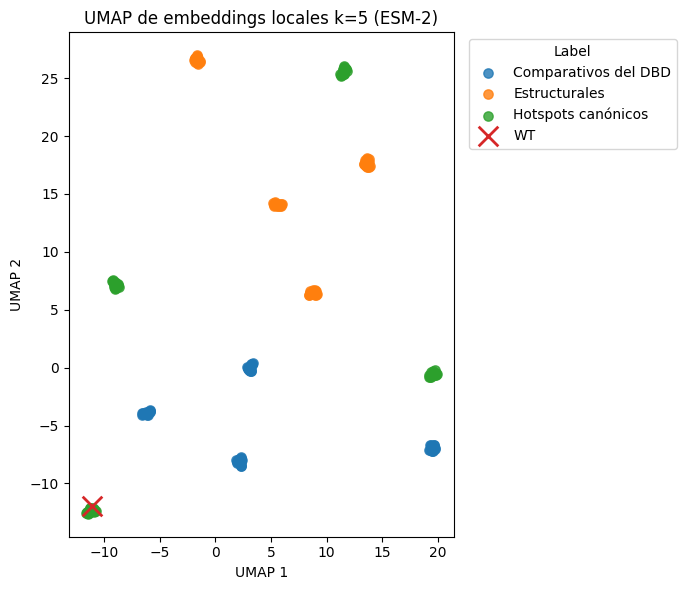

In [ ]:
X = k5_emb
labels_arr = group_list

print("Shape embeddings:", X.shape)
print("Número de labels:", len(labels_arr))

assert X.shape[0] == len(labels_arr), "Mismatch entre embeddings y labels"

X_scaled = StandardScaler().fit_transform(X)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)

X_umap = reducer.fit_transform(X_scaled)

df_umap = pd.DataFrame({
    "UMAP1": X_umap[:, 0],
    "UMAP2": X_umap[:, 1],
    "label": labels_arr,
})

plt.figure(figsize=(7, 6))
for label in np.unique(labels_arr):
    subset = df_umap[df_umap["label"] == label]
    if label == "WT":
        plt.scatter(subset["UMAP1"], subset["UMAP2"], label=label,
                    alpha=1.0, s=200, marker="x", linewidths=2)
    else:
        plt.scatter(subset["UMAP1"], subset["UMAP2"], label=label,
                    alpha=0.8, s=45)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP de embeddings locales k=5 (ESM-2)")
plt.legend(title="Label", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 13. Análisis de propiedades fisicoquímicas de las mutaciones

Se anota cada mutante con propiedades del aminoácido wild-type y mutante:
carga, clase fisicoquímica, tamaño, aromaticidad e hidrofobicidad.
Luego se analiza la correlación entre cambios fisicoquímicos y distancia coseno.

In [ ]:
# ── Diccionarios de propiedades ──

# Carga neta simplificada
aa_charge = {
    "R": "positive", "K": "positive", "H": "positive",
    "D": "negative", "E": "negative",
    "A": "neutral", "C": "neutral", "F": "neutral", "G": "neutral",
    "I": "neutral", "L": "neutral", "M": "neutral", "N": "neutral",
    "P": "neutral", "Q": "neutral", "S": "neutral", "T": "neutral",
    "V": "neutral", "W": "neutral", "Y": "neutral"
}

# Clase fisicoquímica
aa_class = {
    "A": "hydrophobic", "V": "hydrophobic", "I": "hydrophobic",
    "L": "hydrophobic", "M": "hydrophobic", "F": "hydrophobic",
    "W": "hydrophobic", "Y": "hydrophobic",
    "S": "polar", "T": "polar", "N": "polar", "Q": "polar",
    "C": "polar", "G": "special", "P": "special",
    "D": "charged", "E": "charged", "K": "charged",
    "R": "charged", "H": "charged"
}

# Tamaño aproximado
aa_size = {
    "G": "small", "A": "small", "S": "small", "C": "small",
    "D": "medium", "P": "medium", "N": "medium", "T": "medium",
    "E": "medium", "V": "medium", "Q": "medium", "H": "medium",
    "I": "large", "L": "large", "M": "large", "K": "large",
    "R": "large", "F": "large", "Y": "large", "W": "large"
}

# Conjuntos para clasificación
aromatic = {"F", "W", "Y"}
aliphatic = {"A", "V", "I", "L", "M"}
polar_aa = {"S", "T", "N", "Q", "C"}
charged_aa = {"D", "E", "K", "R", "H"}

In [ ]:
def annotate_mutation_type(df):
    """Agrega columnas con propiedades fisicoquímicas de cada mutación."""
    df = df.copy()

    # Carga
    df["wt_charge"] = df["wt_aa"].map(aa_charge)
    df["mut_charge"] = df["mut_aa"].map(aa_charge)

    # Clase
    df["wt_class"] = df["wt_aa"].map(aa_class)
    df["mut_class"] = df["mut_aa"].map(aa_class)

    # Tamaño
    df["wt_size"] = df["wt_aa"].map(aa_size)
    df["mut_size"] = df["mut_aa"].map(aa_size)

    # Cambios binarios (¿cambió la propiedad?)
    df["charge_change"] = df["wt_charge"] != df["mut_charge"]
    df["class_change"] = df["wt_class"] != df["mut_class"]
    df["size_change"] = df["wt_size"] != df["mut_size"]

    # Casos especiales: introducción/remoción de residuos estructuralmente importantes
    df["introduces_proline"] = df["mut_aa"] == "P"
    df["introduces_glycine"] = df["mut_aa"] == "G"
    df["introduces_cysteine"] = df["mut_aa"] == "C"
    df["removes_proline"] = df["wt_aa"] == "P"
    df["removes_glycine"] = df["wt_aa"] == "G"
    df["removes_cysteine"] = df["wt_aa"] == "C"

    # Aromaticidad
    df["wt_aromatic"] = df["wt_aa"].isin(aromatic)
    df["mut_aromatic"] = df["mut_aa"].isin(aromatic)
    df["aromatic_change"] = df["wt_aromatic"] != df["mut_aromatic"]

    # Grupo de hidrofobicidad
    def hydro_group(aa):
        if aa in aliphatic or aa in aromatic:
            return "hydrophobic"
        elif aa in polar_aa:
            return "polar"
        elif aa in charged_aa:
            return "charged"
        elif aa in {"G", "P"}:
            return "special"
        else:
            return "other"

    # Fix: use the actual sets

    df["wt_hydro_group"] = df["wt_aa"].apply(hydro_group)
    df["mut_hydro_group"] = df["mut_aa"].apply(hydro_group)
    df["hydro_group_change"] = df["wt_hydro_group"] != df["mut_hydro_group"]

    # Mutación conservativa (sin cambio de carga, clase ni tamaño)
    df["is_conservative_like"] = (
        (~df["charge_change"]) &
        (~df["class_change"]) &
        (~df["size_change"])
    )

    return df

df_annot = annotate_mutation_type(df)
df_annot.head()

,mutant,position,wt_aa,mut_aa,group,global_cosine_similarity_to_WT,global_cosine_distance_to_WT,global_euclidean_distance_to_WT,k0_cosine_similarity_to_WT,k0_cosine_distance_to_WT,...,removes_proline,removes_glycine,removes_cysteine,wt_aromatic,mut_aromatic,aromatic_change,wt_hydro_group,mut_hydro_group,hydro_group_change,is_conservative_like
0,R175A,175,R,A,Hotspots canónicos,0.999950,0.000050,0.086051,0.886312,0.113688,...,False,False,False,False,False,False,charged,hydrophobic,True,False
1,R175C,175,R,C,Hotspots canónicos,0.999968,0.000032,0.071122,0.905606,0.094394,...,False,False,False,False,False,False,charged,polar,True,False
2,R175D,175,R,D,Hotspots canónicos,0.999926,0.000074,0.104173,0.876742,0.123258,...,False,False,False,False,False,False,charged,charged,False,False
3,R175E,175,R,E,Hotspots canónicos,0.999918,0.000082,0.110315,0.882806,0.117194,...,False,False,False,False,False,False,charged,charged,False,False
4,R175F,175,R,F,Hotspots canónicos,0.999963,0.000037,0.075071,0.889230,0.110770,...,False,False,False,False,True,True,charged,hydrophobic,True,False


### 13.1 Impacto del cambio de carga en la distancia coseno (k=5)

Se compara la distribución de distancias k=5 entre mutaciones que cambian la carga neta
y las que la conservan.

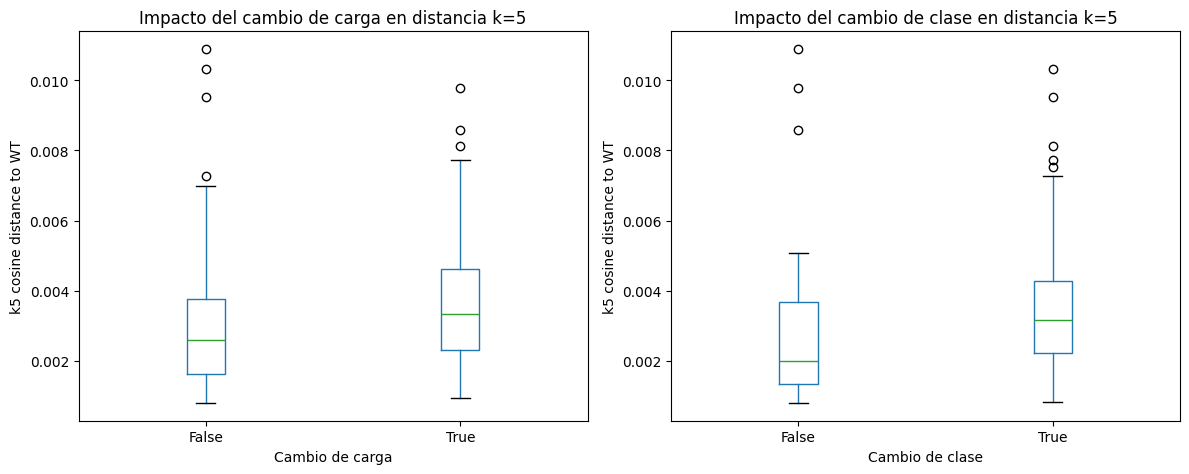

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot: charge_change vs k5 distance
df_annot.boxplot(column="k5_cosine_distance_to_WT", by="charge_change", grid=False, ax=axes[0])
axes[0].set_title("Impacto del cambio de carga en distancia k=5")
axes[0].set_xlabel("Cambio de carga")
axes[0].set_ylabel("k5 cosine distance to WT")

# Boxplot: class_change vs k5 distance
df_annot.boxplot(column="k5_cosine_distance_to_WT", by="class_change", grid=False, ax=axes[1])
axes[1].set_title("Impacto del cambio de clase en distancia k=5")
axes[1].set_xlabel("Cambio de clase")
axes[1].set_ylabel("k5 cosine distance to WT")

plt.suptitle("")
plt.tight_layout()
plt.show()

### 13.2 Impacto combinado: número de propiedades cambiadas vs distancia

Se cuenta cuántas propiedades (carga, clase, tamaño) cambian simultáneamente
y se compara con la distancia coseno.

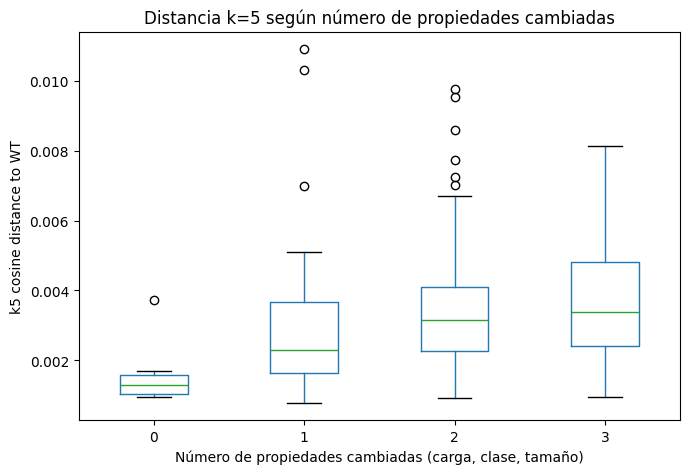

In [ ]:
df_annot["n_changes"] = (
    df_annot["charge_change"].astype(int) +
    df_annot["class_change"].astype(int) +
    df_annot["size_change"].astype(int)
)

fig, ax = plt.subplots(figsize=(7, 5))
df_annot.boxplot(column="k5_cosine_distance_to_WT", by="n_changes", grid=False, ax=ax)
ax.set_title("Distancia k=5 según número de propiedades cambiadas")
ax.set_xlabel("Número de propiedades cambiadas (carga, clase, tamaño)")
ax.set_ylabel("k5 cosine distance to WT")
plt.suptitle("")
plt.tight_layout()
plt.show()

## 14. Exportar resultados

Se guardan los DataFrames principales como archivos CSV para análisis posteriores.

In [ ]:
# Guardar métricas detalladas por mutante
df.to_csv("tp53_synthetic_mutants_embedding_metrics.csv", index=False, float_format='%.6f')

# Guardar resumen agregado por posición
summary_by_position.to_csv("tp53_position_summary_embedding_metrics.csv", index=False, float_format='%.6f')

# Guardar DataFrame anotado con propiedades fisicoquímicas
df_annot.to_csv("tp53_mutants_annotated.csv", index=False, float_format='%.6f')

print("Archivos guardados:")
print("  - tp53_synthetic_mutants_embedding_metrics.csv")
print("  - tp53_position_summary_embedding_metrics.csv")
print("  - tp53_mutants_annotated.csv")

Archivos guardados:
  - tp53_synthetic_mutants_embedding_metrics.csv
  - tp53_position_summary_embedding_metrics.csv
  - tp53_mutants_annotated.csv
